11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (60000, 28, 28)
Testing data: (10000, 28, 28)


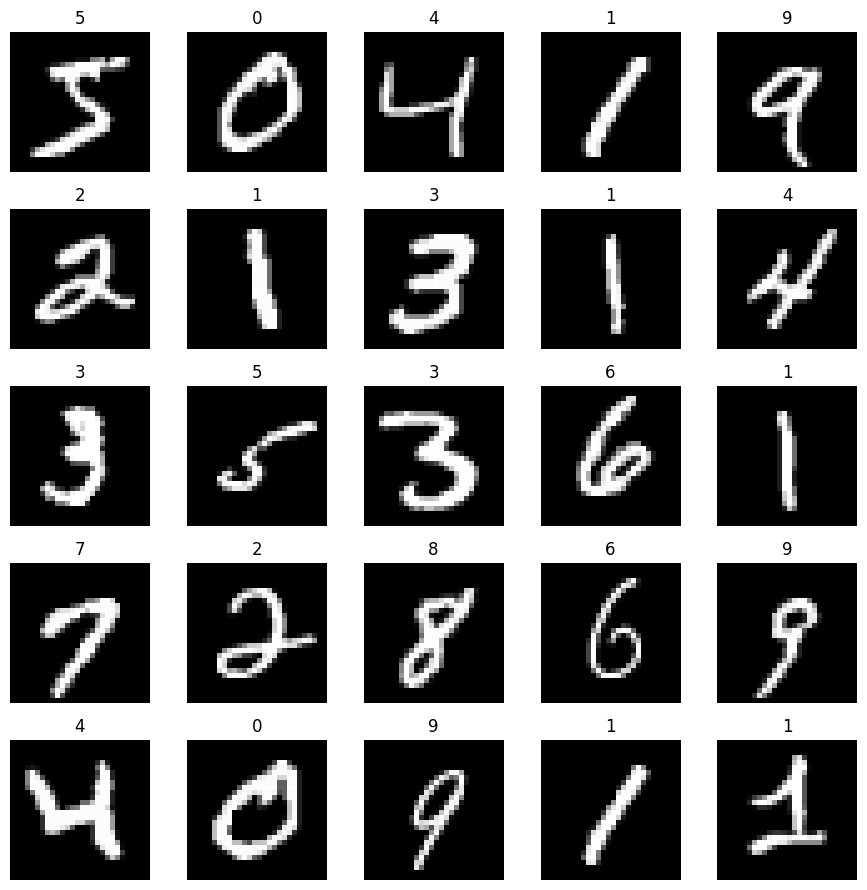

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 48s 110ms/step - accuracy: 0.9240 - loss: 0.2578 - val_accuracy: 0.9803 - val_loss: 0.0637
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - accuracy: 0.9800 - loss: 0.0646 - val_accuracy: 0.9873 - val_loss: 0.0447
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - accuracy: 0.9860 - loss: 0.0445 - val_accuracy: 0.9888 - val_loss: 0.0345
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 111ms/step - accuracy: 0.9896 - loss: 0.0336 - val_accuracy: 0.9862 - val_loss: 0.0418
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 106ms/step - accuracy: 0.9908 - loss: 0.0274 - val_accuracy: 0.9900 - val_loss: 0.0322
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 106ms/step - accuracy: 0.9928 - loss: 0.0229 - val_accuracy: 0.9898 - val_loss: 0.0345
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 109ms/step - accuracy: 0.9941 - loss: 0.0188 - val_accuracy: 0.9897 - val_loss: 0.0337
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 106ms/step - accuracy: 0.9944 - loss: 0

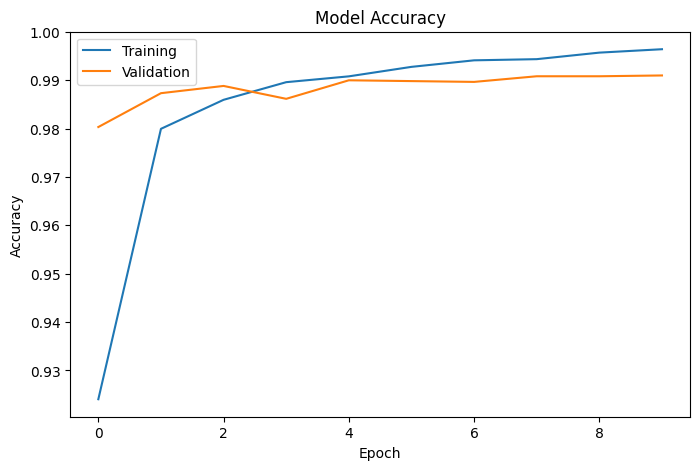

313/313 - 3s - 9ms/step - accuracy: 0.9893 - loss: 0.0366
Accuracy: 0.989300012588501
Accuracy (%): 98.9300012588501


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

x_train = x_train[..., tf.newaxis] / 255.0
x_test = x_test[..., tf.newaxis] / 255.0

labels = [str(i) for i in range(10)]

plt.figure(figsize=(9, 9))

for index in range(25):
    plt.subplot(5, 5, index + 1)
    plt.imshow(x_train[index].squeeze(), cmap="gray")
    plt.title(labels[y_train[index]])
    plt.axis("off")

plt.tight_layout()
plt.show()

model = models.Sequential([
    layers.Conv2D(
        filters=32,
        kernel_size=3,
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    layers.MaxPooling2D(pool_size=2),

    layers.Conv2D(
        filters=64,
        kernel_size=3,
        activation="relu"
    ),

    layers.MaxPooling2D(pool_size=2),

    layers.Conv2D(
        filters=64,
        kernel_size=3,
        activation="relu"
    ),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dense(10)
])

model.summary()

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

model.compile(
    optimizer="adam",
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

results = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

plt.figure(figsize=(8, 5))

plt.plot(results.history["accuracy"])
plt.plot(results.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Validation"])

plt.show()

loss, accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=2
)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)
